# 9-1. 의사결정나무와 앙상블
## 9-1-1. 의사결정나무

데이터를 분류하거나 예측하기 위한 트리(Tree) 구조의 모델이며, 조건을 담은 노드와 노드를 잇는 엣지로 구성된다.  

| 구분       | 설명                                   |
| -------- | ------------------------------------ |
| 💡 목적    | 분류(Classification) 또는 회귀(Regression) |
| 🌲 구조    | 노드와 엣지로 구성된 트리 구조                    |
| 🔀 분기 기준 | 불순도(정보이득, 지니지수 등)를 최소화하도록 선택         |
| 🧠 작동 방식 | 데이터를 조건에 따라 반복적으로 분할하여 예측 결과 도출      |


| 요소                        | 설명                           |
| ------------------------- | ---------------------------- |
| **루트 노드** (Root Node)     | 트리의 시작점 (모든 데이터를 포함)         |
| **내부 노드** (Internal Node) | 조건에 따라 데이터를 나누는 지점           |
| **단말 노드** (Leaf Node)     | 최종 예측 결과를 나타냄                |
| **분할 기준**                 | 정보이득, 지니지수 (분류) / 분산 감소 (회귀) |


- 장점: 해석이 쉽고 시각화 가능, 범주형, 수치형 변수 모두 처리 가능, 스케일링 불필요, 이상치나 결측치에 강건함
- 단점: 과적합 가능성 높음(트리크기 제한), 작은 변화에 민감함(데이터가 조금만 달라져도 구조바뀜), 일반화 성능 낮음,   
  데이터 밖의 새로운 데이터 예측 불가(시계열 데이터에 맞지 않는 모델)

<불순도 종류>
- 분류: 엔트로피, 지니불순도, log loss
- 회귀: squared error, friedman MSE, absolute error, poisson

| 불순도 지표                    | 수식 또는 정의                     | 설명                         | 특징              |
| ------------------------- | ---------------------------- | -------------------------- | --------------- |
| **지니 불순도** (Gini Impurity) | $G = 1 - \sum p_i^2$         | 각 클래스의 비율 $p_i$의 제곱을 뺀 값   | 가장 널리 쓰임 |
| **엔트로피** (Entropy)        | $H = -\sum p_i \log_2 p_i$   | 정보 이론 기반의 지표. 클래스의 혼잡도를 측정 | 지니보다 조금 더 계산 복잡 |


In [1]:
# 불순도 계산공식
from collections import Counter
import numpy as np

def entropy(data):
    if type(data[0]) == float: #클래스별 확률을 입력값으로 받는 경우
        ratio = np.array(data)
        value = -(ratio*np.log2(ratio)).sum()
    else: #범주형일 경우
        cnt = Counter(data)
        freq = np.array(list(cnt.values()))
        ratio = freq/freq.sum()
        value = -(ratio*np.log2(ratio)).sum()
    return value

def gini(data):
    if type(data[0]) == float: #클래스별 확률을 입력값으로 받는 경우
        ratio = np.array(data)
        value =1-(ratio**2).sum()
    else: #범주형일 경우
        cnt = Counter(data)
        freq = np.array(list(cnt.values()))
        ratio = freq/freq.sum()
        value =1-(ratio**2).sum()
    return value   

In [2]:
# 이진분류 데이터
r1 = ['A']*3+['B']*2
e1 = entropy(r1)
e2 = entropy([3/5, 2/5])
print(f"엔트로피: {e1:.3f} / {e2:.3f}") #0에 가까울수록 좋음(불순도니까)

g1 = gini(r1)
g2 = gini([3/5, 2/5])
print(f"지니불순도: {g1:.3f} / {g2:.3f}")

엔트로피: 0.971 / 0.971
지니불순도: 0.480 / 0.480


In [3]:
# 다중 클래스
r2 = ['A', 'B', 'C', 'C']+['D']*4

e1 = entropy(r2)
e2 = entropy([0.125, 0.125, 0.25 , 0.5])
print(f"엔트로피: {e1:.3f} / {e2:.3f}") #0에 가까울수록 좋음(불순도니까)

g1 = gini(r2)
g2 = gini([0.125, 0.125, 0.25 , 0.5])
print(f"지니불순도: {g1:.3f} / {g2:.3f}")

엔트로피: 1.750 / 1.750
지니불순도: 0.656 / 0.656


#### 특성 중요도: feature importance

트리를 만드는 결정에 각 피쳐가 얼마나 사용되었는지를 나타내는 값으로, 특성 중요도의 전체 합은 1임  
어떤 특성의 중요도가 낮더라도 이 특성이 중요하지 않은 것은 아니며, 트리분기 시 다른 피처가 동일한 정보를 가지고 있어서 해당 피처를  
사용하지 않았을 수도 있기 때문임.  

특성중요도는 항상 양수이며, 해당 피처가 종속변수의 어느 클래스를 지지하는지(분류), 양의 관계인지 음의 관계인지(회귀) 알 수 없다.  

<과적합 제어전략>  
- 사전 가지치기(pre-pruning): 트리의 최대깊이, 리프의 최대갯수, 노드가 분할할 데이터의 최소개수 지정으로 트리생성 규제
  - 하이퍼파라미터: max-depth, max_leaf_nodes, min_samples_leaf, min_samples_split
- 사후 가지치기(post-pruning): 트리를 만든 후 데이터 포인트가 적은 노드를 삭제하거나 병합

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

cancer = load_breast_cancer()
X = cancer.data
Y = cancer.target

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, stratify=Y, random_state=42)

dt = DecisionTreeClassifier(max_depth=3, criterion='gini')
dt.fit(train_X, train_Y)

pred = dt.predict(test_X)
print(f"정확도: {dt.score(test_X, test_Y):.3f}")

정확도: 0.944


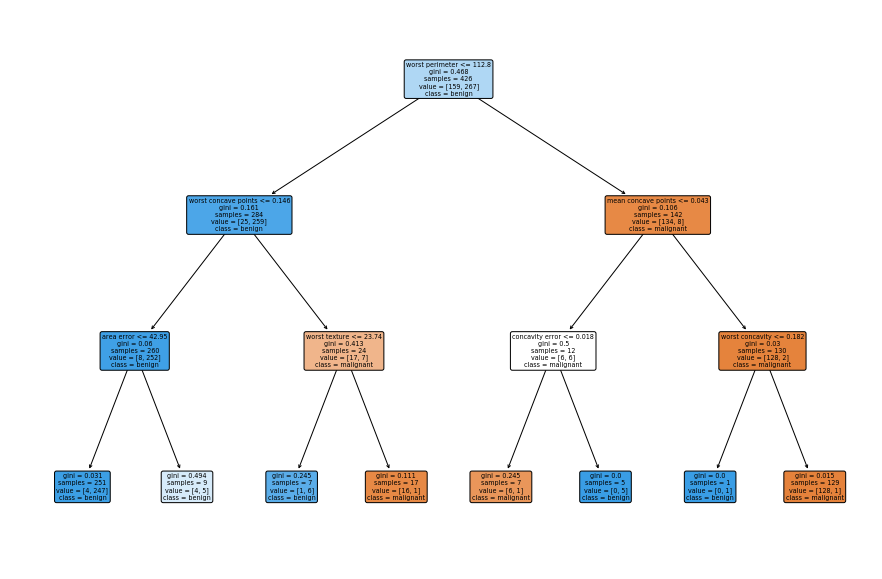

In [5]:
#결정트리 시각화
plt.figure(figsize=(15, 10))
plot_tree(dt, class_names=cancer.target_names, feature_names=cancer.feature_names, impurity=True, filled=True, rounded=True)
plt.show()

In [6]:
print(export_text(dt)) #텍스트 분기 확인

|--- feature_22 <= 112.80
|   |--- feature_27 <= 0.15
|   |   |--- feature_13 <= 42.95
|   |   |   |--- class: 1
|   |   |--- feature_13 >  42.95
|   |   |   |--- class: 1
|   |--- feature_27 >  0.15
|   |   |--- feature_21 <= 23.74
|   |   |   |--- class: 1
|   |   |--- feature_21 >  23.74
|   |   |   |--- class: 0
|--- feature_22 >  112.80
|   |--- feature_7 <= 0.04
|   |   |--- feature_16 <= 0.02
|   |   |   |--- class: 0
|   |   |--- feature_16 >  0.02
|   |   |   |--- class: 1
|   |--- feature_7 >  0.04
|   |   |--- feature_26 <= 0.18
|   |   |   |--- class: 1
|   |   |--- feature_26 >  0.18
|   |   |   |--- class: 0



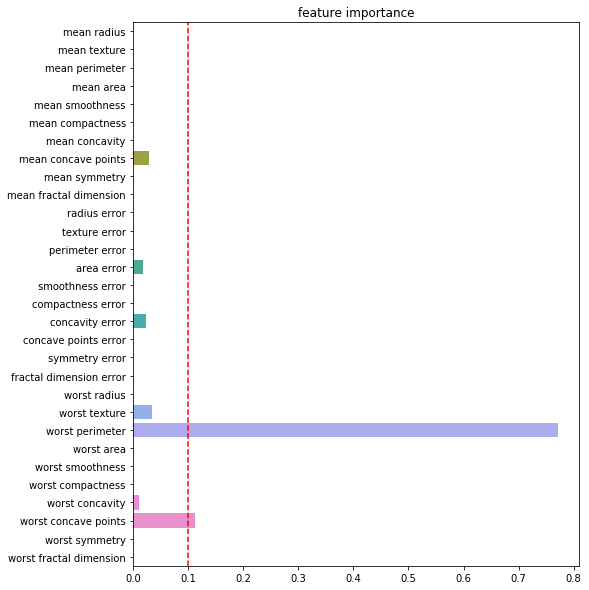

In [7]:
import seaborn as sns

#feature importance 확인
plt.figure(figsize=(8, 10))
fi = dt.feature_importances_
fn = cancer.feature_names
sns.barplot(fi, fn)
plt.title('feature importance')
plt.axvline(x=0.1, color='r', linestyle='--')
plt.show()

## 9-1-2. 앙상블

단일 모델보다 좋은 결과를 얻기 위해, 여러 모델을 결합한 모델  
최종 예측값을 얻기 위해 여러 모델(weak learner)의 예측값을 기반으로 voting을 진행한다.  
- hard voting: 각 모델들의 예측값을 바탕으로 다수결 투표 방식
- soft voting: 예측값들의 평균 또는 가중치 합을 사용하는 방식
- 스태킹: 모델의 예측값을 피처(입력값)로 지정하고, 실제값을 타겟으로 하여 새로운 모델을 생성 후 최종 예측값을 예측하는 방식

### 배깅(bootstrap aggregating)

중복을 허용한 랜덤 샘플링으로 원본과 동일한 크기의 여러 개의 훈련세트를 만들고 각각을 학습시킨 후 집계하는 방식  

샘플링은 일반적으로 원본데이터의 절반을 사용하는 방식인 subbagging을 사용하며, BaggingClassifier, BaggingRegressor의 max_samples로  
훈련세트의 크기를 지정할 수 있음
회귀분석을 할 시 이상치의 영향을 많이 받는 평균 대신 중위수를 사용하는 방식을 robust bagging이라고 함

- OOB: 랜덤샘플링이므로 데이터가 샘플에 한 번도 포함되지 않을 확률이 36.8%인데, 이러한 데이터를 OOB라고 함.  
  훈련에 사용되지 않은 데이터이므로 검증과 테스트에 사용할 수 있다. 
  - BaggingClassifier, BaggingRegressor의 oob_score = True → oob_score_로 검증

In [40]:
from sklearn.ensemble import BaggingClassifier

dt = DecisionTreeClassifier(max_depth=3, min_samples_leaf=4)
bagging = BaggingClassifier(dt, n_estimators=50, oob_score=True, random_state=0, max_samples=0.5, max_features=.5) #사용샘플수, 피처수
bagging.fit(train_X, train_Y)
pred1 = bagging.predict(test_X)
prob1 = bagging.predict_proba(test_X)[:, 1] #1에 대한 예측확률

#모델 학습결과
print(f"train set score: {bagging.score(train_X, train_Y):.3f}")
print(f"test set score: {bagging.score(test_X, test_Y):.3f}")
print(f"oob score: {bagging.oob_score_:.3f}")

#샘플수
print(f"첫번째 estimator bootstrap 샘플수: {len(bagging.estimators_samples_[0])}, 원본 샘플수: {len(train_X)}")
print(f"첫번째 estimator bootstrap 샘플수: {len(bagging.estimators_features_[0])}, 원본 샘플수: {train_X.shape[1]}")

train set score: 0.972
test set score: 0.958
oob score: 0.955
첫번째 estimator bootstrap 샘플수: 213, 원본 샘플수: 426
첫번째 estimator bootstrap 샘플수: 15, 원본 샘플수: 30


### 부스팅(boosting)

학습할 때마다 잔차가 큰 데이터 포인트들의 가중치를 높여가며 일련의 모델들을 생성하는 방법  
이전 모델이 갖는 오차를 줄이는 방향으로 다음 모델을 순차적으로 생성한다.  
주요 부스팅 알고리즘으로 Adaptive boosting, Gradient boosting, Stochastic gradient boosting이 있음

- Adaptive boosting(AdaBoost)  
  잔차에 따라 데이터의 가중치를 조절하는 부스팅의 초기버전, 앞서 생성한 모델의 예측결과와 실제 데이터의 차이가 클 수록 해당 데이터는  
  높은 가중치를 받게되며, 각 데이터마다 얻어진 가중치들은 그 다음 모델이 학습할 때 입력 값의 일부로 주어진다. 매 반복마다 가중치는  
  업데이트되며, 예측하기 어려운 데이터에 대해 더 집중해서 학습을 하도록 모델을 생성한다. 
  - AdaBoostClassifier, AdaBoostRegressor
  
- Gradient Boosting  
  전체 데이터의 오차를 최적화하는 접근법을 사용했다는 점에서 Adaboost와 차이가 있음. 가중치를 조정하는 대신 모델이 유사잔차를 학습  
  이 때, 잔차가 그레디언트로 표현되며 경사하강법을 사용하여 다음에 추가될 트리가 예측해야 할 값 보정
  - GradientBoostingRegressor, GradientBoostingClassifier: max_depth를 일반적으로 5 이하의 값 사용하며, learning_rate로 모델 복잡성제어
  
- Stochastic gradient boosting  
  학습할 때마다 데이터와 예측변수를 샘플링하는 방식으로 그래디언트 부스팅에 랜덤요소 추가  
  - XGBClassifier, XGBRegressor: subsampler(샘플링 입력데이터 비율 조정), eta(모델 복잡성) 조정 필요

train set score: 1.000
test set score: 0.965


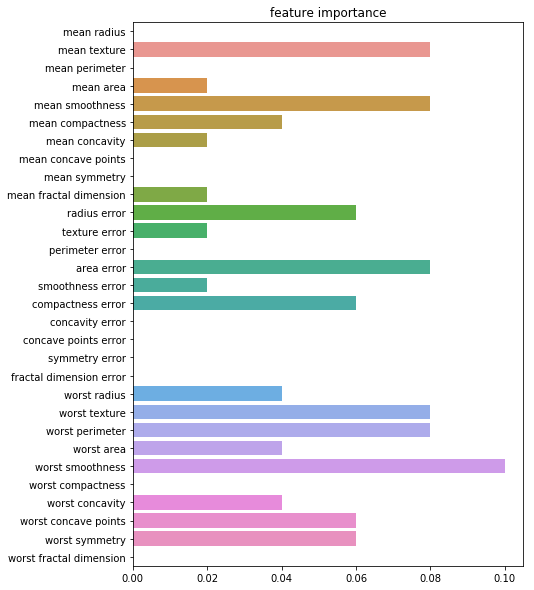

In [33]:
#adaboost
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(random_state=42, n_estimators=50)
ada.fit(train_X, train_Y)

pred2 = ada.predict(test_X)
prob2 = ada.predict_proba(test_X)[:, 1] # label 1 예측값

#성능
print(f"train set score: {ada.score(train_X, train_Y):.3f}")
print(f"test set score: {ada.score(test_X, test_Y):.3f}")

#feature importance
fi = ada.feature_importances_
fn = cancer.feature_names
plt.figure(figsize=(7, 10))
sns.barplot(fi, fn)
plt.title('feature importance')
plt.show()

train set score: 1.000
test set score: 0.944


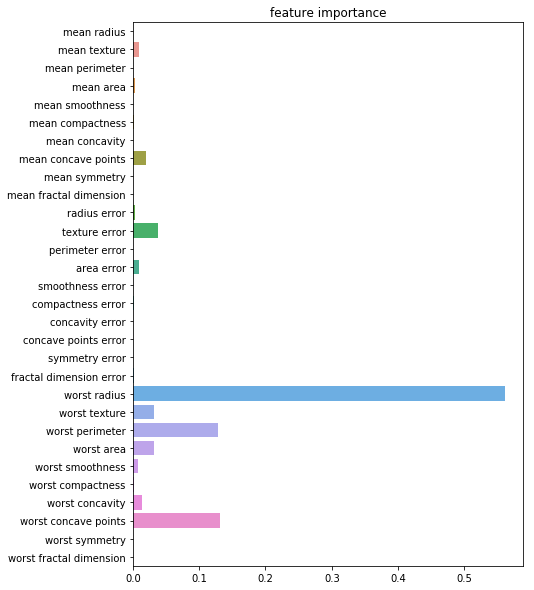

In [34]:
#그래디언트 부스팅- classifier
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(random_state=42, n_estimators=50)
gbc.fit(train_X, train_Y)
pred3 = gbc.predict(test_X)
prob3 = gbc.predict_proba(test_X)[:, 1] # label 1 예측값

#성능
print(f"train set score: {gbc.score(train_X, train_Y):.3f}")
print(f"test set score: {gbc.score(test_X, test_Y):.3f}")

#feature importance
fi = gbc.feature_importances_
fn = cancer.feature_names
plt.figure(figsize=(7, 10))
sns.barplot(fi, fn)
plt.title('feature importance')
plt.show()

train set score: 1.000
test set score: 0.972


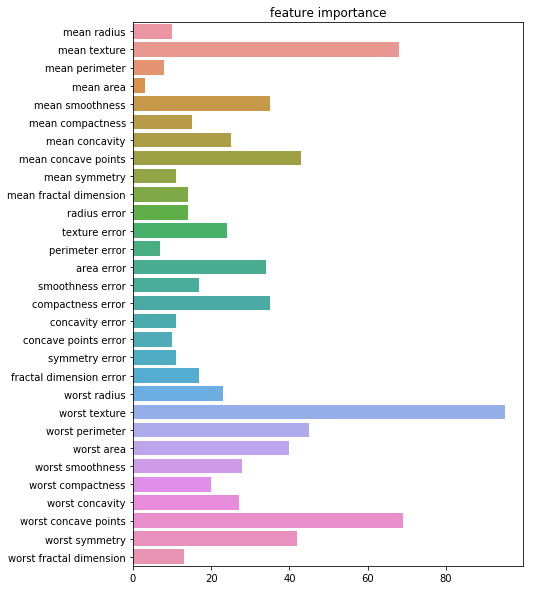

In [35]:
#그래디언트 부스팅-Light GBM
from lightgbm import LGBMClassifier, plot_importance, plot_tree, create_tree_digraph

lgbm = LGBMClassifier(n_estimators=50)
lgbm.fit(train_X, train_Y)
pred4 = lgbm.predict(test_X)
prob4 = lgbm.predict_proba(test_X)[:, 1] # label 1 예측값

#성능
print(f"train set score: {lgbm.score(train_X, train_Y):.3f}")
print(f"test set score: {lgbm.score(test_X, test_Y):.3f}")

#feature importance
fi = lgbm.feature_importances_
fn = cancer.feature_names
plt.figure(figsize=(7, 10))
sns.barplot(fi, fn)
plt.title('feature importance')
plt.show()

#트리시각화
# fig, ax = plt.subplots(1, 1, figsize=(15, 10))
# plot_tree(lgbm, ax=ax)
# plt.show()

train set score: 0.995
test set score: 0.944


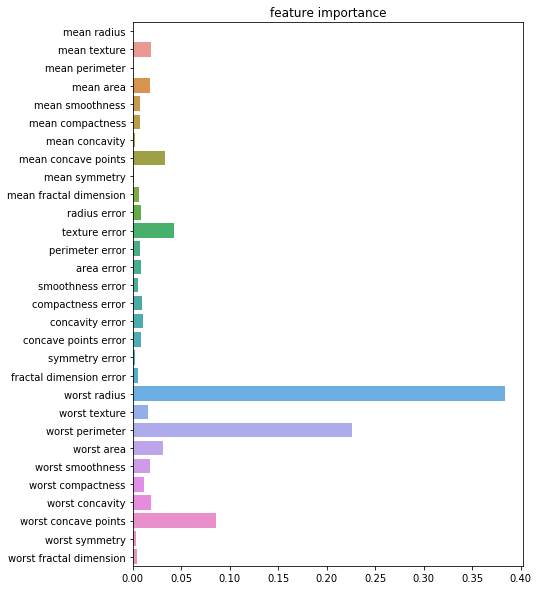

In [36]:
#stochastic gradient boosting-xgboost

from xgboost import plot_importance, XGBClassifier

xgb = XGBClassifier(objective='binary:logistic', n_estimators=50, eval_metric='logloss')
xgb.fit(train_X, train_Y)
pred5 = xgb.predict(test_X)
prob5 = xgb.predict_proba(test_X)[:, 1] # label 1 예측값

#성능
print(f"train set score: {xgb.score(train_X, train_Y):.3f}")
print(f"test set score: {xgb.score(test_X, test_Y):.3f}")

#feature importance
fi = xgb.feature_importances_
fn = cancer.feature_names
plt.figure(figsize=(7, 10))
sns.barplot(fi, fn)
plt.title('feature importance')
plt.show()

### 랜덤포레스트와 extra-tree

- 랜덤포레스트
  트리들이 서로 최대한 달라지도록 트리 생성 시 무작위성을 주입하는 방법. 무작위성은 데이터 포인트를 부트스트랩 샘플링하고,  
  데이터의 특성을 무작위로 선택함으로써 구현함. 일반적인 의사결정트리는 가지를 분할할 때 불순도 기준값이 최소화되도록 전체  
  특성을 살펴서 분할지점을 결정하는 반면, 랜덤포레스트는 랜덤하게 선택한 일부 특성만으로 불순도 기준값을 최소화하는 분할지점을  
  결정하여 무작위성이 높아짐과 동시에 학습 속도가 빨라지게 됨  
  - 장점: 병렬 실행 가능, 피처의 수가 적기 때문에 계산비용이 낮음, OOB 데이터 활용하여 추가적 데이터 업이 모델 검증 가능,  
    매개변수 튜닝을 많이 하지 않아도 잘 동작하며, 스케일링이 필요없음, 단일성능보다 예측 성능이 뛰어남
  - 단점: 결과에 대한 직관적인 해석이 불가능, 고차원의 희소한 데이터에서는 잘 작동하지 않음

- Extra-tree(ERT, Extremely randomize tree)  
  랜덤포레스트와 거의 같은 방법으로 모델을 구축하나, 가지 분할 시 랜덤 설정한 임계값을 사용하여 분할  
  - 장점: 계산비용이 적음
  - 단점: 무작위 분할 때문에 일반화 성능을 높이기 위해 많은 트리를 만들어야 함
  - ExtraTreeClassifier, ExtraTreeRegressor

train set score: 1.000
test set score: 0.951


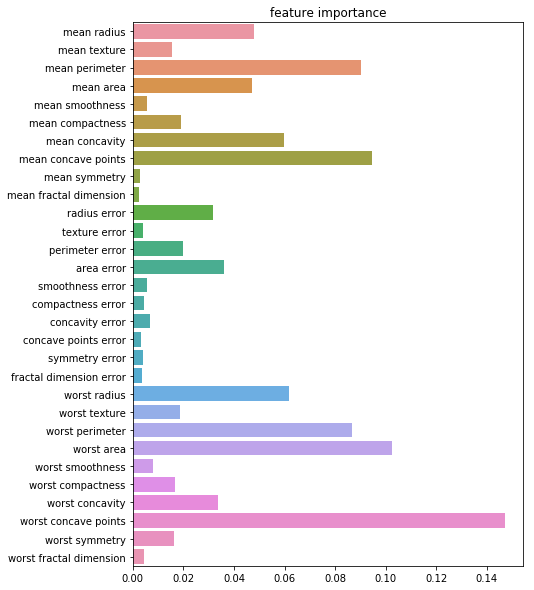

In [37]:
#random forest: 단일트리보다 많은 특성이 0이상의 중요도를 가짐

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(train_X, train_Y)
pred6 = rf.predict(test_X)
prob6 = rf.predict_proba(test_X)[:, 1] # label 1 예측값

#성능
print(f"train set score: {rf.score(train_X, train_Y):.3f}")
print(f"test set score: {rf.score(test_X, test_Y):.3f}")

#feature importance
fi = rf.feature_importances_
fn = cancer.feature_names
plt.figure(figsize=(7, 10))
sns.barplot(fi, fn)
plt.title('feature importance')
plt.show()

train set score: 1.000
test set score: 0.965


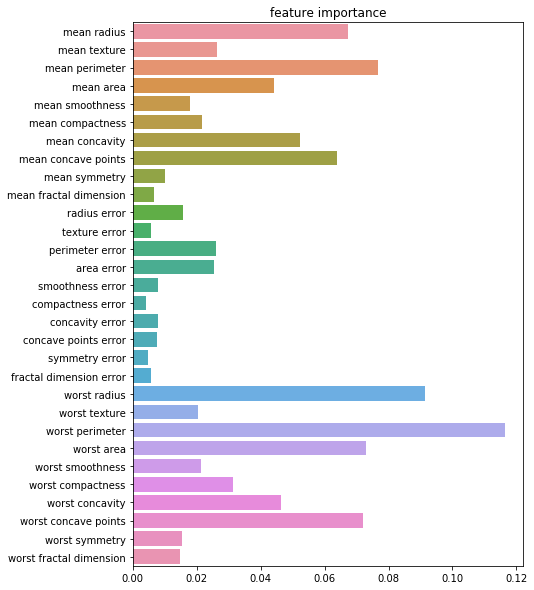

In [38]:
#extra tree
from sklearn.ensemble import ExtraTreesClassifier

ex = ExtraTreesClassifier(n_estimators=50, random_state=42)
ex.fit(train_X, train_Y)
pred7 = ex.predict(test_X)
prob7 = ex.predict_proba(test_X)[:, 1] # label 1 예측값

#성능
print(f"train set score: {ex.score(train_X, train_Y):.3f}")
print(f"test set score: {ex.score(test_X, test_Y):.3f}")

#feature importance
fi = ex.feature_importances_
fn = cancer.feature_names
plt.figure(figsize=(7, 10))
sns.barplot(fi, fn)
plt.title('feature importance')
plt.show()

### 스태킹
각 앙상블 모델로부터 얻은 예측확률 혹은 예측값을 데이터로 삼아 한번 더 모델링하는 방법  
기존 모델들의 성능보다 더 개선된 성능의 모델을 얻을 수 있음

In [44]:
title = ['bagging', 'adaboost', 'gboost', 'lgbm', 'xgboost', 'random_forest', 'xtree']
preds = [pred1, pred2, pred3, pred4, pred5, pred6, pred7] 
probs = [prob1, prob2, prob3, prob4, prob5, prob6, prob7]

import pandas as pd
prob_df = pd.DataFrame(probs).T #각 모델의 예측확률을 feature로 재학습, y는 test_y
meta_model = RandomForestClassifier(n_estimators=30, random_state=42, max_depth=3)
meta_model.fit(prob_df, test_Y)
m_pred = meta_model.predict(prob_df)

In [47]:
from sklearn.metrics import accuracy_score

for title, pred in zip(title, preds):
    score = accuracy_score(test_Y, pred)
    print(f"{title} model score: {score:.3f}")
print(f"**stacking score: {accuracy_score(test_Y, m_pred):.3f}")

bagging model score: 0.958
adaboost model score: 0.965
gboost model score: 0.944
lgbm model score: 0.972
xgboost model score: 0.944
random_forest model score: 0.951
xtree model score: 0.965
**stacking score: 1.000


# 9-2. KNN

최근접 이웃 알고리즘으로 분류와 회귀에 사용되는 비모수 지도학습이다. 이웃 ㄷ이터에 기반한 계산만 하고, 데이터를 통한 학습과정이   
없으므로 lazy model이라고 함. 모든 변수가 수치형이어야 한다.
- 분류: 값을 예측하고자 하는 데이터와 유사한 피처 값을 가지는 k개의 이웃 데이터를 찾은 다음, 다수가 속한 클래스로 값을 예측
- 회귀: 유사한 k개의 데이터들의 평균값을 계산, 거리가 가까운 이웃일 수록 평균에 더 많이 기여하도록 가중치를 줄 수 있음  

<장단점>
- 장점: 단순하고 구현이 쉬운 모델, 하이퍼파이미터 조정이 많이 필요하지 않음
- 단점: 모든 데이터를 사용하므로 훈련세트가 크면 예측이 느려짐, 고차원 데이터에서 잘 동작하지 않으며 특성값 대부분이 0인 희소한  
  데이터에서는 특히 잘 작동하지 않는다. 데이터 전처리과정이 중요함

In [48]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X = load_iris().data
Y = load_iris().target

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, stratify=Y, random_state=42)


knn = KNeighborsClassifier(n_neighbors=3, weights='uniform', p=2) #균등거리계산, 유클리디안
knn.fit(train_X, train_Y)

train_score = knn.score(train_X, train_Y)
test_score = knn.score(test_X, test_Y)
print(f"train score: {train_score:.3f} / test score: {test_score:.3f}")

distance, index = knn.kneighbors(test_X)

i = 0 #첫번째 데이터
print("원본데이터:", test_X[i])
print("이웃 간 거리:", distance[i])
print("이웃 인덱스:", index[i])

train score: 0.955 / test score: 0.974
원본데이터: [4.4 3.2 1.3 0.2]
이웃 간 거리: [0.2236068 0.3       0.3      ]
이웃 인덱스: [111  78  76]


In [50]:
#knn 회귀
from sklearn.datasets import load_diabetes
from sklearn.neighbors import KNeighborsRegressor

X = load_diabetes().data[:, :5]
Y = load_diabetes().target

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=42)

knnr = KNeighborsRegressor(n_neighbors=15, weights='distance', p=1) #거리가중치, 맨하튼
knnr.fit(train_X, train_Y)

train_score = knnr.score(train_X, train_Y)
test_score = knnr.score(test_X, test_Y)
print(f"train score: {train_score:.3f} / test score: {test_score:.3f}")

distance, index = knnr.kneighbors(test_X)

i = 0 #첫번째 데이터
print("원본데이터:", test_X[i])
print("이웃 간 거리:", distance[i])
print("이웃 인덱스:", index[i])

train score: 1.000 / test score: 0.333
원본데이터: [ 0.04534098 -0.04464164 -0.00620595 -0.01599922  0.1250187 ]
이웃 간 거리: [0.07398492 0.08946084 0.10071145 0.10320351 0.11656133 0.12081142
 0.1243277  0.12814594 0.13016781 0.13742446 0.13831093 0.14359146
 0.14421323 0.14804621 0.14835501]
이웃 인덱스: [197 318  34 270 193  53 203 241 232  91 214 215 304  77  69]


# 9-3. SVM
이진 클래스로 분류되는 데이터를 학습하여 새로운 데이터가 어느 클래스에 속할지 판단하는 비확률적 이진 선형 분류모델  
데이터가 사상된 공간에서 이진 클래스를 구분하는 결정경계들 중 어떠한 데이터도 포함하지 않는 가장 큰 폭을 가진 경계(마진)을 찾음  
이 결정경계와 가장 가까이 있는 일부의 훈련 데이터들을 서포트벡터라고 하며, 새로운 데이터는 서포트 벡터와의 거리를 측정하여  
예측값을 결정함. 데이터에 비선형 특성을 추가하거나, 커널기법을 사용하여 비선형 분류가 가능
- 다항식 커널, 가우시안 커널(RBF) 등
- kernel: linear, poly, **rbf**, sigmoid, precomputed
- gamma: 가우시안 커널 폭의 역수, 0보다 큰 값 입력, 작은 값은 모델의 복잡도를 낮추며, 큰 값은 복잡도를 높임
- C: 규제를 의미하며 0~1사이 값, 각 포인트의 중요도 제한, C가 커지면 정확도가 올라가며, 낮아지면 일반화된다. 

<장단점>
- 장점: 데이터의 특성이 적어도 복잡한 결정경계 생성 가능, 저/고차원 데이터 모두 잘 작동
- 단점: 대용량 데이터에서 잘 작동하지 않음, 스케일링 등 전처리와 매개변수 설정이 까다로움, 예측결과에 대한 모델 설명이 어려움

In [56]:
# svm classifier
from sklearn.svm import SVC

X = load_breast_cancer().data
Y = load_breast_cancer().target

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, stratify=Y, random_state=42)

# 노스케일링
svm = SVC(C=0.1, kernel='rbf', gamma='auto')
svm.fit(train_X, train_Y)

train_score1 = svm.score(train_X, train_Y)
test_score1 = svm.score(test_X, test_Y)
print(f"[스케일링 전] train score: {train_score1:.3f} / test score: {test_score1:.3f}")

#스케일링 후
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X2 = sc.fit_transform(X)
train_X, test_X, train_Y, test_Y = train_test_split(X2, Y, stratify=Y, random_state=42)

svm2 = SVC(C=0.1, kernel='rbf', gamma='auto')
svm2.fit(train_X, train_Y)

train_score2 = svm2.score(train_X, train_Y)
test_score2 = svm2.score(test_X, test_Y)
print(f"[스케일링 후] train score: {train_score2:.3f} / test score: {test_score2:.3f}")

#기타등등
print("support vector 수:", len(svm2.dual_coef_[0])) #또는 coef_
print("support vector 중요도:", svm2.dual_coef_[0][0:5]) #또는 coef_
print("support vector 인덱스:", svm2.support_[0:5]) #또는 coef_
print("support vector 값:", svm2.support_vectors_[0:5].shape) #또는 coef_

[스케일링 전] train score: 0.627 / test score: 0.629
[스케일링 후] train score: 0.962 / test score: 0.937
support vector 수: 194
support vector 중요도: [-0.1 -0.1 -0.1 -0.1 -0.1]
support vector 인덱스: [ 2  3  5  7 11]
support vector 값: (5, 30)


In [65]:
#regression 
from sklearn.svm import SVR

X = load_diabetes().data
Y = load_diabetes().target

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=42)

# 노스케일링
svm = SVR(C=15, kernel='rbf', gamma='auto')
svm.fit(train_X, train_Y)

train_score1 = svm.score(train_X, train_Y)
test_score1 = svm.score(test_X, test_Y)
print(f"[스케일링 전] train score: {train_score1:.3f} / test score: {test_score1:.3f}")

#스케일링 후
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X2 = sc.fit_transform(X)
train_X, test_X, train_Y, test_Y = train_test_split(X2, Y, random_state=42)

svm2 = SVR(C=15, kernel='rbf', gamma='auto')
svm2.fit(train_X, train_Y)

train_score2 = svm2.score(train_X, train_Y)
test_score2 = svm2.score(test_X, test_Y)
print(f"[스케일링 후] train score: {train_score2:.3f} / test score: {test_score2:.3f}")

#기타등등
print("support vector 수:", len(svm2.dual_coef_[0])) #또는 coef_
print("support vector 중요도:", svm2.dual_coef_[0][0:5]) #또는 coef_
print("support vector 인덱스:", svm2.support_[0:5]) #또는 coef_
print("support vector 값:", svm2.support_vectors_[0:5].shape) #또는 coef_

[스케일링 전] train score: 0.034 / test score: 0.060
[스케일링 후] train score: 0.552 / test score: 0.528
support vector 수: 331
support vector 중요도: [-15. -15. -15.  15.  15.]
support vector 인덱스: [0 1 2 3 4]
support vector 값: (5, 10)


# 9-4. 나이브 베이즈 분류

특성들 사이의 독립을 가정하는 베이즈 정리를 활용한 확률분류기로, 머신러닝의 지도학습 알고리즘에 속함

- 조건부 독립 가정: 모든 특성(feature)은 클래스가 주어지면 서로 독립이라 가정합니다 
- 생성 모델: 클래스별로 특징의 분포를 모델링하며, 각 특성의 확률을 곱해서 전체 우도(likelihood)를 계산합니다 
- 매우 빠르고 가벼움: 특성을 개별적으로 계산할 수 있어 큰 데이터셋과 고차원 특성에서도 효율적입니다

| 항목        | 내용                                                |
| --------- | ------------------------------------------------- |
| **가정**    | 특성 간 조건부 독립                                       |
| **계산 방식** | MAP 추정을 위한 prior × likelihood 곱, 로그 합 계산          |
| **장점**    | 단순·빠름·고차원 효율·작은 데이터에서도 잘 작동                       |
| **단점**    | 독립 가정 불만족, zero-frequency, 확률 과신, 상호작용 무시, 불균형 민감 |

<종류>
- GaussianNB: 예측변수가 연속형 변수일 때 사용, 예측변수들의 우도가 가우시안 분포를 따른다고 가정
- BernoulliNB: 예측변수가 이진 데이터일 때 사용
- MultinomialNB: 예측변수가 빈도데이터일 때 사용
- CategoricalNB: 예측변수가 카테고리적 분포를 따르는 데이터일 때 사용
- CompletementNB: MultinomialNB 알고리즘을 개선하여 불균형 데이터셋에서도 잘 작동

In [78]:
# 조건부확률 구하기: 뽑힌 사람이 여자일 때, 그 사람이 안경을 썼을 확률?

dt = pd.DataFrame([[18, 5], [12, 3]], index=['남자', '여자'], columns=['안경o', '안경x'])
dt['성별sum'] = dt.sum(axis=1)
dt.loc['안경sum', :] = dt.sum(axis=0)
display(dt)

p1 = 15/38 #여자일 확률
p2 = 30/38  #안경쓸 확률
p3 = 12/30 #안경썼는데 여자일 확률

print(f"P(안경o|여자): {(p3*p2)/p1:.3f}")

,안경o,안경x,성별sum
남자,18.0,5.0,23.0
여자,12.0,3.0,15.0
안경sum,30.0,8.0,38.0


P(안경o|여자): 0.800


In [84]:
# 베이즈 정리를 통해 전확률과 사후확률 구하기
## B가 일어났을 때 A1이 일어날 확률은? P(A1|B)
from pandas import DataFrame #P(A1) + P(A2) = 1
a1, a2 = 0.7, 0.3 #P(A1), P(A2)
b_a1, b_a2 = 0.2, 0.9 #P(B|A1), P(B|A2)
b = a1*b_a1 + a2*b_a2 #P(B) 전확률 정리
table1 = DataFrame({"사건":['A1', 'A2'], 
                  '사전확률_P(Ai)':[a1, a2], 
                  '조건부확률_P(B|Ai)':[b_a1, b_a2], 
                  '결합확률_P(Ai*B)':[a1*b_a1, a2*b_a2], 
                  '사후확률_P(Ai|B)':[ a1*b_a1/b, a2*b_a2/b]})
print(f"P(B)={b:.3f}")
print("P(A1|B)={:.3f}".format(table1.query('사건=="A1"')['사후확률_P(Ai|B)'].values[0]))
display(table1.round(3))

P(B)=0.410
P(A1|B)=0.341


,사건,사전확률_P(Ai),조건부확률_P(B|Ai),결합확률_P(Ai*B),사후확률_P(Ai|B)
0,A1,0.7,0.2,0.14,0.341
1,A2,0.3,0.9,0.27,0.659


In [82]:
## B가 일어났을 때 A1이 일어날 확률은? P(A1|B)
#P(A1) + P(A2) + P(A3) = 1
a1, a2, a3 = 0.2, 0.35, 0.45 #P(A1), P(A2), P(A3)
b_a1, b_a2, b_a3 = 0.02, 0.04, 0.03 #P(B|A1), P(B|A2), P(B|A3)
b = a1*b_a1 + a2*b_a2+ a3*b_a3 #P(B) 전확률 정리
table2 = DataFrame({"사건":['A1', 'A2', 'A3'], 
                  '사전확률_P(Ai)':[a1, a2, a3], 
                  '조건부확률_P(B|Ai)':[b_a1, b_a2, b_a3], 
                  '결합확률_P(Ai*B)':[a1*b_a1, a2*b_a2, a3*b_a3], 
                  '사후확률_P(Ai|B)':[ a1*b_a1/b, a2*b_a2/b, a3*b_a3/b]})
print("P(B)={:.3f}".format(b)) # 전확률
print("P(A1|B)={:.3f}".format(table2.query('사건=="A1"')['사후확률_P(Ai|B)'].values[0]))
display(table2.round(3))

P(B)=0.032
P(A1|B)=0.127


,사건,사전확률_P(Ai),조건부확률_P(B|Ai),결합확률_P(Ai*B),사후확률_P(Ai|B)
0,A1,0.20,0.02,0.004,0.127
1,A2,0.35,0.04,0.014,0.444
2,A3,0.45,0.03,0.014,0.429


feature 확인:  [ 0.  0.  7. 15. 13.  1.  0.  0.  0.  8. 13.  6. 15.  4.  0.  0.  0.  2.
  1. 13. 13.  0.  0.  0.  0.  0.  2. 15. 11.  1.  0.  0.  0.  0.  0.  1.
 12. 12.  1.  0.  0.  0.  0.  0.  1. 10.  8.  0.  0.  0.  8.  4.  5. 14.
  9.  0.  0.  0.  7. 13. 13.  9.  0.  0.]
target 확인:  3
Train score 0.828, Test score 0.847
예측한 숫자 :[8] 
 실제숫자: 8 


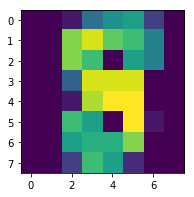

In [103]:
# GaussianNB
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
X = load_digits().data
y = load_digits().target
idx = 3
print("feature 확인: ", X[idx])
print("target 확인: ", y[idx])

X_train, X_test, y_train, y_test = train_test_split(X, y)
GNB = GaussianNB()
GNB.fit(X_train, y_train)
train_score = GNB.score(X_train, y_train)
test_score = GNB.score(X_test, y_test)
print(f"Train score {train_score:.3f}, Test score {test_score:.3f}")

#실제 숫자 이미지와 예측한 숫자 확인하기
pred = GNB.predict(X_test[idx].reshape(-1, len(X_test[idx])))
print(f"예측한 숫자 :{pred} \n 실제숫자: {y_test[idx]} ")
plt.imshow(X_test[idx].reshape(8, 8))
plt.show()

In [102]:
# spam mails [출처: https://www.kaggle.com/datasets/venky73/spam-mails-dataset]
emails = pd.read_csv('https://raw.githubusercontent.com/algoboni/pythoncodebook1-1/main/9-4_spam.csv').sample(300).reset_index(drop=True) #300개만 샘플링
print(f"원본 데이터: \n\n{emails.head(10)}")

# dtm(document-term matrix)은 각 단어를 feature로, 문장 내 단어출현빈도를 값으로 가짐
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
xv = cv.fit_transform(emails['email_title'])
dtm = pd.DataFrame(xv.toarray(), columns=cv.get_feature_names())
print("DTM")
display(dtm.head(3))

# 각 단어출현빈도를 feature로, spam 여부를 target으로 함
X = dtm
Y = emails['spam']
train_X, test_X, train_Y, test_Y = train_test_split(X, Y, stratify=Y, random_state=0)

원본 데이터: 

                                         email_title  spam
0  Subject: ocean star brown bag - may 17 th , 20...     0
1  Subject: re : shell meters for october\r\nshel...     0
2  Subject: entex revised estimates for 4 / 00\r\...     0
3  Subject: hpl nom for july 28 , 2000 - - one da...     0
4  Subject: re : new sitara desk request _ ena - ...     0
5  Subject: pops it team temporarily moving to al...     0
6  Subject: re : network at wed , 11 aug 2004 18 ...     1
7  Subject: sale to shoreline\r\nfyi\r\n- - - - -...     0
8  Subject: fw : lower colorado river authority\r...     0
9  Subject: please re - map hpl zone 4 from a / s...     0
DTM


,00,000,001,00221,00298,003,006,009,01,0100,...,zjwcqg,zobyuve,zomba,zone,zounds,zrdggv,zs,ztv,zuybzbq,zwallet
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [154]:
# BernoulliNB
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB(binarize = 0) # 이진이 아닌경우 이진화
bnb.fit(train_X, train_Y)
train_score = bnb.score(train_X, train_Y)
test_score = bnb.score(test_X, test_Y)
print(f"train score: {train_score:.3f} / test score: {test_score:.3f}")

#스팸여부 확인
idx = 0
pred = bnb.predict(test_X.iloc[idx].values.reshape(1, -1))
print(f"예측: {pred[0]} / 실제: {test_Y.iloc[idx]}")

#사전확률
print(f"각 클래스 사전확률: false({bnb.class_log_prior_[0]:.3f}) / true({bnb.class_log_prior_[1]:.3f})")

#사후확률: 클래스별 중요도
result = pd.DataFrame(bnb.feature_log_prob_, columns=cv.get_feature_names(), index=['False', 'True'])
display(result.iloc[:, 1000:1008])

# .feature_log_prob_는 각 class일 때 해당 feature인 단어가 나올 로그 확률을 의미한다. 
# 이 확률값이 높을수록, 해당 class일 때 해당 feature인 단어가 나올 확률이 높다는 의미이다. 
# 따라서, False에 대한 확률값이 낮을수록, True에 대한 확률값이 높을수록 spam일 확률이 높다.

train score: 0.809 / test score: 0.760
예측: 1 / 실제: 1
각 클래스 사전확률: false(-0.347) / true(-1.226)


,actions,activated,active,actively,activities,activity,acton,acts
False,-5.081404,-4.388257,-4.388257,-5.081404,-3.982792,-3.289645,-3.471966,-5.081404
True,-3.120895,-4.219508,-3.120895,-4.219508,-4.219508,-4.219508,-4.219508,-3.526361


In [155]:
# MultinomialNB
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
mnb.fit(train_X, train_Y)
train_score = mnb.score(train_X, train_Y)
test_score = mnb.score(test_X, test_Y)
print(f"train score: {train_score:.3f} / test score: {test_score:.3f}")

#스팸여부 확인
idx = 0
pred = mnb.predict(test_X.iloc[idx].values.reshape(1, -1))
print(f"예측: {pred[0]} / 실제: {test_Y.iloc[idx]}")

#사전확률
print(f"각 클래스 사전확률: false({mnb.class_log_prior_[0]:.3f}) / true({mnb.class_log_prior_[1]:.3f})")

#사후확률: 클래스별 중요도
result = pd.DataFrame(mnb.feature_log_prob_, columns=cv.get_feature_names(), index=['False', 'True'])
display(result.iloc[:, 1000:1008])

# .feature_log_prob_는 각 class일 때 해당 feature인 단어가 나올 로그 확률을 의미한다. 
# 이 확률값이 높을수록, 해당 class일 때 해당 feature인 단어가 나올 확률이 높다는 의미이다. 
# 따라서, False에 대한 확률값이 낮을수록, True에 대한 확률값이 높을수록 spam일 확률이 높다.

train score: 0.987 / test score: 0.907
예측: 1 / 실제: 1
각 클래스 사전확률: false(-0.347) / true(-1.226)


,actions,activated,active,actively,activities,activity,acton,acts
False,-10.332702,-9.234089,-9.639555,-10.332702,-8.946407,-7.336969,-8.135477,-10.332702
True,-8.680841,-9.779454,-8.680841,-9.779454,-9.779454,-9.779454,-9.779454,-9.086307


# 9-5. 인공신경망

11493376/11490434 [==============================] - 1s 0us/step
전체 클래스:  [0 1 2 3 4 5 6 7 8 9]
클래스별 데이터 수:  [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


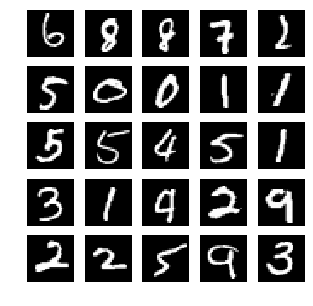

[[6 8 8 7 2]
 [5 0 0 1 1]
 [5 5 4 5 1]
 [3 1 9 2 9]
 [2 2 5 9 3]]
(28, 28)


In [156]:
# Tensorflow에서 MNIST 데이터 불러오기
import numpy as np
from tensorflow.keras.datasets.mnist import load_data
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

(x_train, y_train), (x_test, y_test) = load_data(path='mnist.npz')

# 트레인셋의 unique들(타겟값들, 클래스들)과 그 개수 확인 
unique, counts = np.unique(y_train, return_counts = True)
print("전체 클래스: ", unique)
print("클래스별 데이터 수: ", counts)

# 훈련 데이터세트에서 25개의 숫자 샘플 추출하기
indexes = np.random.randint(0, x_train.shape[0], size=25)
images = x_train[indexes]
labels = y_train[indexes]

# 25개의 샘플 숫자 확인하기
plt.figure(figsize=(5,5))
for i in range(len(indexes)):
    image = images[i] # image = 28*28픽셀의 숫자 매트릭스 (각 숫자는 0~255)
    plt.subplot(5,5, i+1) #subplot(가로, 세로, 순서)
    plt.imshow(image, cmap='gray')
    plt.axis('off')
plt.show()
print(labels.reshape(-1,5))
print(image.shape)

In [159]:
# Tensorflow로 MLP 구축하기
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.regularizers import l2, l1

## 모델 구축을 위한 데이터 전처리

# 타겟변수를 0~9의 희박한 스칼라로 표현하는 것은 클래스별 확률을 출력하는 신경망 예측 계층에 적합하지 않기 때문에 이를 원핫벡터로 변환한다. (0~9 숫자를 각각 1x10 행렬로 변환)
y_train2 = to_categorical(y_train)
y_test2 = to_categorical(y_test)
print("변환 전 타겟변수: ", y_train[0])
print("변환 후 타겟변수: ", y_train2[0])

# 이미지 차원 (정사각형으로 가정)
image_size = x_train.shape[1] #데이터의 픽셀값들 (28, 28) 
input_size = image_size * image_size

# X는 shape 변환 (28*28를 1*784) 및 변수 스케일링
x_train2 = x_train.reshape(-1, input_size)
x_test2 = x_test.reshape(-1, input_size)
print("X 데이터 형태 변환: ", x_test.shape," -> ", x_test2.shape)

# 각 픽셀값을 0~255 범위에서 0.0~1.0 범위의 값으로 척도를 변경한다. 원본 픽셀값을 직접 사용할 수도 있지만 그렇게 되면 편향 값이 커져서 모델 훈련이 어려워지므로 입력 데이터를 정규화하는 것이 좋다. 그에 따라 신경망의 출력도 정규화되지만, 훈련이 끝나면 출력 텐서에 255를 곱해서 정수 픽셀값으로 모두 되돌릴 수 있다.
x_train2 = x_train2.astype('float32') / 255
x_test2 = x_test2.astype('float32') / 255


## 모델 구축
input_shape = input_size
batch_size = 128
epochs = 10
hidden_units = 256
dropout = 0.45

# 3개의 계층으로 이루어진 MLP에 정규화 요소, 일반화 요소, 활성화 함수를 적용.
model = Sequential()
model.add(Dense(hidden_units, input_dim=input_shape, kernel_regularizer=l2(0.001)))
model.add(Dropout(dropout))
model.add(Dense(hidden_units, activation='relu'))
model.add(Dropout(dropout))
model.add(Dense(y_train2.shape[1], activation='softmax'))
model.summary()

변환 전 타겟변수:  5
변환 후 타겟변수:  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
X 데이터 형태 변환:  (10000, 28, 28)  ->  (10000, 784)
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_6 (Dense)              (None, 256)               200960    
_________________________________________________________________
dropout_4 (Dropout)          (None, 256)               0         
_________________________________________________________________
dense_7 (Dense)              (None, 256)               65792     
_________________________________________________________________
dropout_5 (Dropout)          (None, 256)               0         
_________________________________________________________________
dense_8 (Dense)              (None, 10)                2570      
Total params: 269,322
Trainable params: 269,322
Non-trainable params: 0
_________________________________________________________________


Train on 60000 samples, validate on 60000 samples
Epoch 1/10
60000/60000 [==============================] - 4s 63us/sample - loss: 0.2216 - acc: 0.9546 - val_loss: 0.1404 - val_acc: 0.9795
Epoch 2/10
60000/60000 [==============================] - 4s 59us/sample - loss: 0.2247 - acc: 0.9537 - val_loss: 0.1378 - val_acc: 0.9798
Epoch 3/10
60000/60000 [==============================] - 3s 58us/sample - loss: 0.2188 - acc: 0.9560 - val_loss: 0.1372 - val_acc: 0.9796
Epoch 4/10
60000/60000 [==============================] - 4s 62us/sample - loss: 0.2189 - acc: 0.9557 - val_loss: 0.1346 - val_acc: 0.9799
Epoch 5/10
60000/60000 [==============================] - 3s 54us/sample - loss: 0.2194 - acc: 0.9562 - val_loss: 0.1330 - val_acc: 0.9807
Epoch 6/10
60000/60000 [==============================] - 4s 62us/sample - loss: 0.2247 - acc: 0.9534 - val_loss: 0.1400 - val_acc: 0.9793
Epoch 7/10
60000/60000 [==============================] - 3s 58us/sample - loss: 0.2190 - acc: 0.9559 - val_loss: 0.

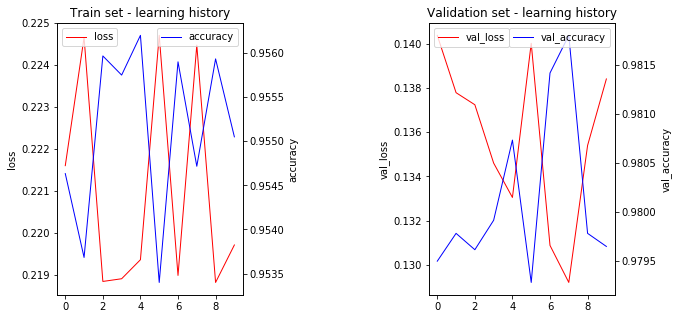


테스트 셋의 loss 0.158, accuracy 0.973

예측값:  [[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]
실제값:  [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


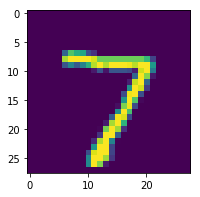

In [167]:
# 모델 컴파일
model.compile(loss=['categorical_crossentropy'], metrics=['accuracy'], optimizer='adam')

# 모델 학습
fitted = model.fit(x_train2, y_train2, validation_data= (x_train2, y_train2,), epochs=epochs, batch_size= batch_size)

# 학습 히스토리 확인
from pandas import DataFrame
result=DataFrame(fitted.history)
print("\n학습 히스토리:\n", result.tail(3))

# 학습 히스토리 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
plt.subplots_adjust(wspace=1)

ax11 = ax1.twinx()

ax1.plot(result['loss'], color='red', label='loss', linewidth=1)
ax1.legend(loc='upper left')
ax1.set_ylabel("loss")

ax11.plot(result['acc'], color='blue', label='accuracy', linewidth=1)
ax11.legend(loc='upper right')
ax11.set_ylabel("accuracy")
plt.title("Train set - learning history")

ax22 = ax2.twinx()

ax2.plot(result['val_loss'], color='red', label='val_loss', linewidth=1)
ax2.legend(loc='upper left')
ax2.set_ylabel("val_loss")

ax22.plot(result['val_acc'], color='blue', label='val_accuracy', linewidth=1)
ax22.legend(loc='upper right')
ax22.set_ylabel("val_accuracy")
plt.title("Validation set - learning history")
plt.show()

# 모델 평가
loss, acc = model.evaluate(x_test2, y_test2, batch_size=batch_size, verbose=False)
print("\n테스트 셋의 loss {:.3f}, accuracy {:.3f}\n".format(loss, acc))

# 모델 예측
j = 0
pred = model.predict(np.reshape(x_test2[j], (-1, input_shape)))
pred.flatten() 
print("예측값: ", pred.round(1))
print("실제값: ", y_test2[j])
plt.imshow(x_test2[j].reshape(-1,image_size))
plt.show()

# 연습문제
1. 다음은 인도 뱅갈루루 집값 데이터이다. 3개의 알고리즘을 선택하여 회귀모델을 생성하고 알고리즘의 장단점과 성능을 비교하시오.   
   (출력변수: 집값)
   
- knn: 기본적인 모델이며, 구현과 설명이 단순하고 쉽다. 다른 모델과 성능 비교군으로 사용한다. 성능이 좋지 않다.
- svm: 저/고차원에서 모두 잘 동작함, 거리기반 모델로 스케일링이 필수
- random forest: 트리기반 앙상블 모델로 비교적 높은 성능을 보여주며, 스케일링이 필요없다.

In [196]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

real = pd.read_csv('https://raw.githubusercontent.com/algoboni/pythoncodebook1-1/main/practice8_BHP2.csv')

X = real.drop(columns=['price'], axis=1)
Y = real['price']

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, test_size=0.2, random_state=42)

cat_cols = ['area_type']
n_cols = ['total_sqft', 'size', 'bath', 'balcony', 'availability']

#knn, svm 용
preprocessor1 = ColumnTransformer(
    [('num', StandardScaler(), n_cols), 
     ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
#랜덤포레스트용
preprocessor2 = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

#모델정의
knn = KNeighborsRegressor(n_neighbors=50, weights='distance', p=2)
svr = SVR(C=50, kernel='linear', gamma='auto', epsilon=0.5)
rf = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)

#파이프라인
k_pipe = Pipeline([('processor', preprocessor1), 
                  ('knn', knn)])
s_pipe = Pipeline([('processor', preprocessor1), 
                  ('svr', svr)])
r_pipe = Pipeline([('processor', preprocessor2), 
                  ('rf', rf)])

k_pipe.fit(train_X, train_Y)
s_pipe.fit(train_X, train_Y)
r_pipe.fit(train_X, train_Y)

model_list = [('knn', k_pipe), ('svm', s_pipe), ('randomforest', r_pipe)]
dt_list = [('train set', train_X, train_Y), ('test set', test_X, test_Y)]

rs = pd.DataFrame(columns=['모델명', 'train rmse', 'test rmse', 'train R2', 'test R2'])

for mn, model in model_list:
    scc = []
    scc2 = []
    for name, x, y in dt_list:
        pred = model.predict(x)
        score = np.sqrt(mean_squared_error(y, pred))
        scc2.append(model.score(x, y))
        scc.append(score)
    rs.loc[len(rs)] = [mn, scc[0], scc[1], scc2[0], scc2[1]]
display(rs) 

,모델명,train rmse,test rmse,train R2,test R2
0,knn,14.156096,45.019970,0.983296,0.730564
1,svm,84.871840,48.513058,0.399589,0.687131
2,randomforest,102.918903,82.673964,0.117100,0.091379


2. price 변수의 중앙값을 기준으로 그 이상이면 높음, 미만이면 낮음으로 이분변수 level을 생성하시오.

In [198]:
real['level'] = np.where(real['price'] >= real['price'].median(), 1, 0)
real.head(3)

,area_type,availability,size,total_sqft,bath,balcony,price,level
0,Super,0,3,1056.0,2,1,39.07,0
1,Plot,1,6,2600.0,5,3,120.00,1
2,Super,1,5,1521.0,3,1,95.00,1


3. 앞서 생성한 이분변수 level을 출력변수로 할 때, 2개의 알고리즘을 선택하여 분류모델을 생성하고 알고리즘의 장단점과 성능을 비교하시오.

  - randomforest, xgbbost

In [206]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

X = real.drop(columns=['price', 'level'], axis=1)
Y = real['level']

X = pd.get_dummies(X, columns=['area_type'], drop_first=True)

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

rf = RandomForestClassifier()
xg = KNeighborsClassifier()

rf.fit(train_X, train_Y)
xg.fit(train_X, train_Y)

model_list = [('xgb', xg), ('randomforest', rf)]
dt_list = [('train set', train_X, train_Y), ('test set', test_X, test_Y)]

for mn, model in model_list:
    for name, x, y in dt_list:
        pred = model.predict(x)
        print(classification_report(y, pred))
        cf = pd.DataFrame(confusion_matrix(y, pred), index=['실제0', '실제1'], columns=['예측0', '예측1'])
        display(cf)

              precision    recall  f1-score   support

           0       0.87      0.88      0.88      2998
           1       0.88      0.87      0.88      2998

    accuracy                           0.88      5996
   macro avg       0.88      0.88      0.88      5996
weighted avg       0.88      0.88      0.88      5996



,예측0,예측1
실제0,2638,360
실제1,385,2613


              precision    recall  f1-score   support

           0       0.82      0.87      0.84       749
           1       0.86      0.81      0.83       750

    accuracy                           0.84      1499
   macro avg       0.84      0.84      0.84      1499
weighted avg       0.84      0.84      0.84      1499



,예측0,예측1
실제0,650,99
실제1,142,608


              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2998
           1       0.94      0.93      0.94      2998

    accuracy                           0.94      5996
   macro avg       0.94      0.94      0.94      5996
weighted avg       0.94      0.94      0.94      5996



,예측0,예측1
실제0,2836,162
실제1,217,2781


              precision    recall  f1-score   support

           0       0.83      0.85      0.84       749
           1       0.84      0.83      0.83       750

    accuracy                           0.84      1499
   macro avg       0.84      0.84      0.84      1499
weighted avg       0.84      0.84      0.84      1499



,예측0,예측1
실제0,634,115
실제1,131,619


4. 앞서 만든 모형들을 통해 집 가격에 있어 중요한 변수 3가지를 선택하고, 그 이유를 설명하시오.

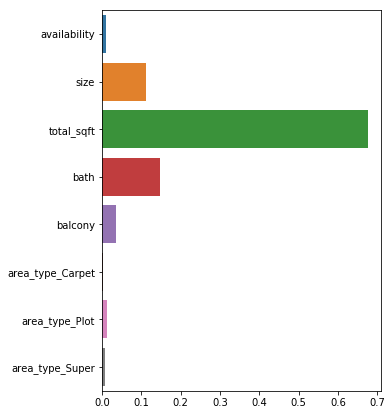

In [213]:
lr = train_X.columns
lf = rf.feature_importances_

plt.figure(figsize=(5, 7))
sns.barplot(lf, lr)
plt.show()

랜덤포레스트의 feature importance 결과를 통해, total_sqrt, bath, size를 모델학습에서의 중요한 변수로 선정한다.